# Bab 2 — Data and Sampling Distributions

Di era big data, **sampling** tetap penting. Data yang kita punya hampir selalu hanyalah **sampel** dari **populasi** yang lebih besar (dan sering tidak diketahui). Bab ini membahas:

1. Random sampling & sample bias
2. Selection bias & regression to the mean
3. Sampling distribution, Central Limit Theorem & standard error
4. Bootstrap
5. Confidence interval
6. Distribusi normal & QQ-plot
7. Distribusi long-tailed
8. Distribusi Student's t
9. Distribusi binomial
10. Distribusi chi-square & F
11. Distribusi Poisson, eksponensial & Weibull

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.utils import resample

%matplotlib inline
sns.set_theme(style='whitegrid')
rng = np.random.default_rng(seed=1)

DATA_URL = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/'

def load(name, **kwargs):
    local = Path('data') / name
    source = local if local.exists() else DATA_URL + name
    return pd.read_csv(source, **kwargs)

## 1. Random Sampling & Sample Bias

- **Populasi** — kumpulan besar (nyata atau teoretis) dari semua data yang ingin kita pelajari.
- **Sampel** — subset dari populasi.
- **N (n)** — ukuran populasi (sampel).
- **Random sampling** — mengambil anggota sampel secara acak, sehingga tiap anggota populasi punya peluang yang sama untuk terpilih.
- **Stratified sampling** — membagi populasi ke dalam **strata** (kelompok), lalu melakukan random sampling di tiap strata.
- **Simple random sample** — hasil random sampling tanpa stratifikasi.
- **Bias** — kesalahan sistematis (bukan acak).
- **Sample bias** — sampel yang tidak merepresentasikan populasi.

Contoh klasik: polling *Literary Digest* 1936 memprediksi Landon menang atas Roosevelt karena sampelnya diambil dari pemilik telepon & mobil (orang kaya). Sampel besar pun tidak berguna kalau bias.

> **Kualitas data sering lebih penting daripada kuantitas data.**

**Sampling with replacement**: observasi dikembalikan ke populasi setelah diambil (bisa terpilih lagi). **Without replacement**: sekali terpilih, tidak bisa terpilih lagi.

In [2]:
# Populasi sintetis: 100.000 pelanggan dari 3 wilayah dengan proporsi & rata-rata belanja berbeda
n_pop = 100_000
wilayah = rng.choice(['Jawa', 'Sumatra', 'Kalimantan'], size=n_pop, p=[0.6, 0.3, 0.1])
mean_belanja = {'Jawa': 500, 'Sumatra': 350, 'Kalimantan': 800}
belanja = np.array([rng.normal(mean_belanja[w], 100) for w in wilayah])
populasi = pd.DataFrame({'wilayah': wilayah, 'belanja': belanja})
print('Mean populasi sebenarnya:', populasi['belanja'].mean().round(2))

# Simple random sample
srs = populasi.sample(n=300, random_state=1)
print('Mean simple random sample:', srs['belanja'].mean().round(2))

# Stratified sample: ambil 1% dari tiap wilayah
strat = populasi.groupby('wilayah', group_keys=False).sample(frac=0.003, random_state=1)
print('Mean stratified sample  :', strat['belanja'].mean().round(2))

# Sampel BIAS: hanya mengambil dari Jawa
bias = populasi[populasi['wilayah'] == 'Jawa'].sample(n=300, random_state=1)
print('Mean sampel bias (Jawa) :', bias['belanja'].mean().round(2))

Mean populasi sebenarnya: 485.29
Mean simple random sample: 482.38
Mean stratified sample  : 487.24
Mean sampel bias (Jawa) : 499.58


## 2. Selection Bias & Regression to the Mean

**Selection bias** — bias yang muncul karena cara memilih observasi, baik sadar maupun tidak.

- **Data snooping** — mengubek-ubek data secara ekstensif sampai menemukan "sesuatu yang menarik". Kalau mencoba cukup banyak hal, pola acak pasti akan terlihat signifikan.
- **Vast search effect** — bias akibat memodelkan data berulang-ulang atau dengan terlalu banyak variabel prediktor.

**Regression to the mean** — fenomena di mana pengukuran ekstrem cenderung diikuti oleh pengukuran yang lebih mendekati rata-rata. Contoh: *rookie of the year* di olahraga sering tampil lebih buruk di tahun kedua (*sophomore slump*). Performa ekstrem = skill + keberuntungan; keberuntungan tidak bertahan.

Simulasi di bawah: skor = kemampuan asli + keberuntungan acak. Kita pilih 5% peserta dengan skor tertinggi di tes 1, lalu lihat skor mereka di tes 2.

In [3]:
n = 10_000
skill = rng.normal(70, 5, n)            # kemampuan asli (tetap)
tes1 = skill + rng.normal(0, 8, n)       # skill + keberuntungan
tes2 = skill + rng.normal(0, 8, n)       # keberuntungan baru

top = tes1 >= np.quantile(tes1, 0.95)
print(f'Rata-rata tes 1 kelompok top 5% : {tes1[top].mean():.1f}')
print(f'Rata-rata tes 2 kelompok yg sama: {tes2[top].mean():.1f}')
print(f'Rata-rata seluruh peserta       : {tes1.mean():.1f}')

Rata-rata tes 1 kelompok top 5% : 89.4
Rata-rata tes 2 kelompok yg sama: 75.2
Rata-rata seluruh peserta       : 70.0


## 3. Sampling Distribution of a Statistic

- **Sample statistic** — metrik yang dihitung dari sampel (misal mean sampel).
- **Data distribution** — distribusi frekuensi dari **nilai-nilai individual** dalam dataset.
- **Sampling distribution** — distribusi frekuensi dari **sebuah statistik sampel** jika kita mengambil banyak sampel dari populasi yang sama.
- **Central Limit Theorem (CLT)** — sampling distribution dari mean cenderung berbentuk **normal** seiring bertambahnya ukuran sampel, *bahkan jika* populasi aslinya tidak normal.
- **Standard error (SE)** — standard deviation dari sampling distribution suatu statistik:

$$SE = \frac{s}{\sqrt{n}}$$

Artinya, untuk memperkecil SE menjadi setengahnya, ukuran sampel harus dinaikkan **4 kali** (*square root of n rule*).

Contoh: `loans_income.csv` berisi pendapatan tahunan peminjam Lending Club. Kita bandingkan distribusi data asli, distribusi mean dari 5 nilai, dan distribusi mean dari 20 nilai.

count     50000.00000
mean      68760.51844
std       32872.03537
min        4000.00000
25%       45000.00000
50%       62000.00000
75%       85000.00000
max      199000.00000
Name: x, dtype: float64


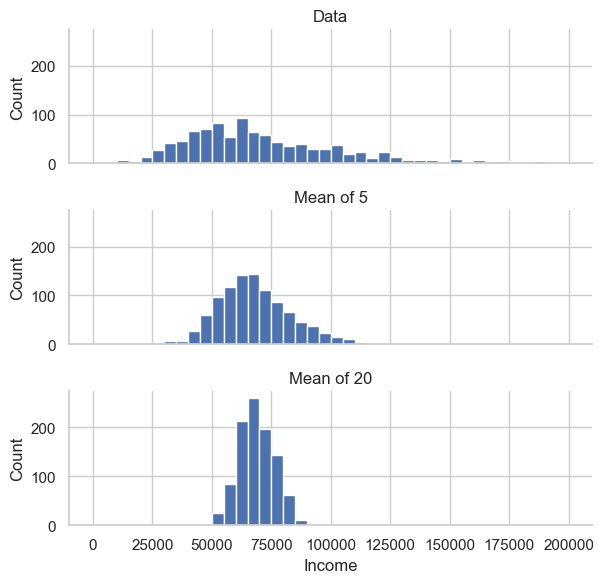

In [4]:
loans_income = load('loans_income.csv').squeeze('columns')
print(loans_income.describe())

sample_data = pd.DataFrame({'income': loans_income.sample(1000, random_state=1),
                            'type': 'Data'})
sample_mean_05 = pd.DataFrame({
    'income': [loans_income.sample(5).mean() for _ in range(1000)],
    'type': 'Mean of 5'})
sample_mean_20 = pd.DataFrame({
    'income': [loans_income.sample(20).mean() for _ in range(1000)],
    'type': 'Mean of 20'})
results = pd.concat([sample_data, sample_mean_05, sample_mean_20])

g = sns.FacetGrid(results, col='type', col_wrap=1, height=2, aspect=3)
g.map(plt.hist, 'income', range=[0, 200000], bins=40)
g.set_axis_labels('Income', 'Count')
g.set_titles('{col_name}')
plt.show()

In [5]:
# Bandingkan SE dari rumus s/sqrt(n) dengan std dari simulasi sampling distribution
for n in [5, 20, 80]:
    means = [loans_income.sample(n).mean() for _ in range(2000)]
    print(f'n={n:3d}  SE rumus = {loans_income.std() / np.sqrt(n):8.1f}   '
          f'SE simulasi = {np.std(means):8.1f}')

n=  5  SE rumus =  14700.8   SE simulasi =  14627.4


n= 20  SE rumus =   7350.4   SE simulasi =   7337.7


n= 80  SE rumus =   3675.2   SE simulasi =   3690.8


Terlihat bahwa (1) semakin besar n, distribusi mean semakin **sempit** dan semakin **mirip normal** (CLT), dan (2) SE hasil rumus hampir sama dengan hasil simulasi.

## 4. Bootstrap

**Bootstrap** adalah cara mudah dan efektif untuk mengestimasi sampling distribution sebuah statistik (atau parameter model) **tanpa asumsi distribusi**. Idenya: anggap sampel kita sebagai "populasi", lalu ambil sampel ulang **dengan pengembalian** (*with replacement*) berkali-kali.

Algoritma bootstrap untuk mean dengan sampel berukuran n:
1. Ambil satu nilai secara acak dari sampel, catat, lalu kembalikan.
2. Ulangi n kali.
3. Hitung mean dari n nilai tersebut.
4. Ulangi langkah 1–3 sebanyak R kali.
5. Gunakan R hasil tersebut untuk: menghitung standard deviation (= estimasi SE), membuat histogram, atau mencari confidence interval.

Istilah:
- **Bootstrap sample** — sampel yang diambil dengan pengembalian dari data observasi.
- **Resampling** — proses mengambil sampel berulang dari data observasi (mencakup bootstrap & permutation).

Bootstrap sangat berguna untuk statistik yang tidak punya rumus SE sederhana, misalnya **median**.

Bootstrap statistics:
original median : 62000.0
bias            : -67.97
std. error      : 211.49


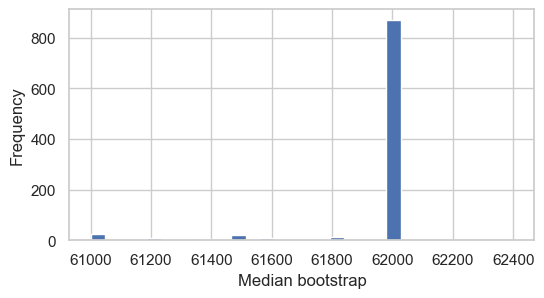

In [6]:
results = []
for _ in range(1000):
    boot_sample = resample(loans_income)
    results.append(boot_sample.median())
results = pd.Series(results)

print('Bootstrap statistics:')
print(f'original median : {loans_income.median()}')
print(f'bias            : {results.mean() - loans_income.median():.2f}')
print(f'std. error      : {results.std():.2f}')

results.plot.hist(bins=30, edgecolor='white', figsize=(6, 3))
plt.xlabel('Median bootstrap')
plt.show()

In [7]:
# Versi numpy (lebih cepat): bootstrap tanpa loop pandas
x = loans_income.to_numpy()
idx = rng.integers(0, len(x), size=(1000, len(x)))
boot_medians = np.median(x[idx], axis=1)
print('SE median (numpy bootstrap):', boot_medians.std().round(2))

SE median (numpy bootstrap): 212.07


## 5. Confidence Interval

**Confidence interval (CI)** adalah rentang nilai yang menyatakan ketidakpastian sebuah estimasi. Sebuah **90% CI** berarti: jika proses sampling & perhitungan interval diulang berkali-kali, sekitar 90% dari interval-interval tersebut akan memuat nilai sebenarnya.

- **Confidence level** — persentase CI (dari sampel berulang) yang diharapkan memuat statistik sebenarnya.
- **Interval endpoints** — batas atas & bawah CI.

**Bootstrap confidence interval** (metode persentil), untuk CI $x\%$:
1. Ambil sampel bootstrap berukuran n, hitung statistiknya.
2. Ulangi R kali.
3. Potong $[(100-x)/2]\%$ dari tiap ujung distribusi hasil R statistik.
4. Titik potong tersebut adalah batas CI.

Semakin tinggi confidence level, semakin **lebar** interval. Semakin besar sampel, semakin **sempit** interval.

Mean sampel 20 data: 55734.1


90% CI (bootstrap persentil): [43048.8, 70355.2]
90% CI (distribusi t)      : [41235.6, 70232.6]


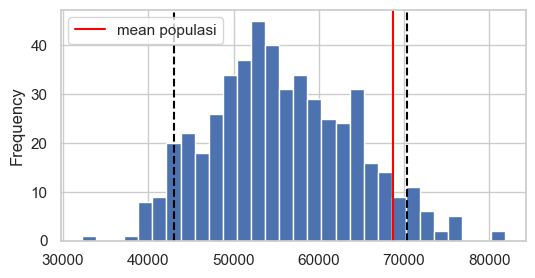

In [8]:
sample20 = resample(loans_income, n_samples=20, replace=False, random_state=3)
print('Mean sampel 20 data:', sample20.mean())

boot_means = pd.Series([resample(sample20).mean() for _ in range(500)])
ci_boot = boot_means.quantile([0.05, 0.95])
print('90% CI (bootstrap persentil):', ci_boot.round(1).tolist())

# Pembanding: CI berbasis distribusi t (rumus klasik)
ci_t = stats.t.interval(0.90, df=len(sample20) - 1,
                        loc=sample20.mean(), scale=stats.sem(sample20))
print('90% CI (distribusi t)      :', np.round(ci_t, 1).tolist())

ax = boot_means.plot.hist(bins=30, figsize=(6, 3), edgecolor='white')
for v in ci_boot:
    ax.axvline(v, color='black', linestyle='--')
ax.axvline(loans_income.mean(), color='red', label='mean populasi')
ax.legend()
plt.show()

In [9]:
# Simulasi arti 'confidence level': berapa persen 90% CI yang benar-benar memuat mean populasi?
mu = loans_income.mean()
hits = 0
for _ in range(1000):
    s = loans_income.sample(50)
    lo, hi = stats.t.interval(0.90, df=49, loc=s.mean(), scale=stats.sem(s))
    hits += lo <= mu <= hi
print(f'{hits / 10:.1f}% interval memuat mean populasi (target 90%)')

89.4% interval memuat mean populasi (target 90%)


## 6. Distribusi Normal

**Distribusi normal** (*Gaussian*) berbentuk lonceng simetris, didefinisikan oleh mean $\mu$ dan standard deviation $\sigma$:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

Sifat penting: sekitar **68%** data berada dalam ±1σ, **95%** dalam ±2σ, dan **99.7%** dalam ±3σ.

- **Error** — selisih antara titik data dengan nilai prediksi / rata-rata.
- **Standardize** — kurangi mean, lalu bagi dengan standard deviation.
- **z-score** — hasil standardisasi: $z = \frac{x - \bar{x}}{s}$.
- **Standard normal** — distribusi normal dengan mean 0 dan std 1.
- **QQ-plot** — plot untuk memvisualisasikan seberapa dekat distribusi sampel dengan distribusi tertentu (misalnya normal). Jika titik-titik mengikuti garis diagonal, data mendekati normal.

> Catatan penting dari buku: **sebagian besar data mentah TIDAK berdistribusi normal**. Kegunaan utama distribusi normal adalah karena banyak *statistik* (mean, error) berdistribusi normal dalam sampling distribution-nya.

In [10]:
# Aturan 68-95-99.7
for k in [1, 2, 3]:
    print(f'P(-{k} < Z < {k}) = {stats.norm.cdf(k) - stats.norm.cdf(-k):.4f}')

# z-score
z = (loans_income - loans_income.mean()) / loans_income.std()
print('Mean z:', round(z.mean(), 4), ' Std z:', round(z.std(), 4))

P(-1 < Z < 1) = 0.6827
P(-2 < Z < 2) = 0.9545
P(-3 < Z < 3) = 0.9973
Mean z: 0.0  Std z: 1.0


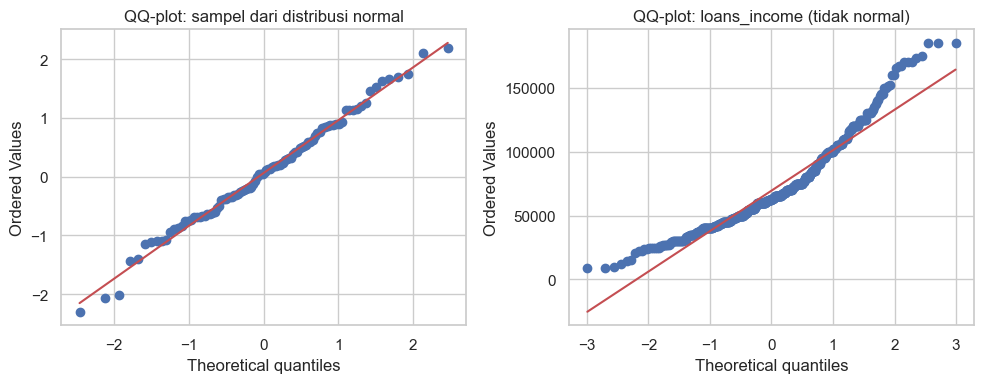

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
norm_sample = stats.norm.rvs(size=100, random_state=1)
stats.probplot(norm_sample, plot=axes[0])
axes[0].set_title('QQ-plot: sampel dari distribusi normal')

stats.probplot(loans_income.sample(500, random_state=1), plot=axes[1])
axes[1].set_title('QQ-plot: loans_income (tidak normal)')
plt.tight_layout()
plt.show()

## 7. Distribusi Long-Tailed

- **Tail** — bagian panjang dan sempit dari distribusi, tempat nilai-nilai ekstrem muncul dengan frekuensi rendah.
- **Skew** — satu ekor distribusi lebih panjang dari ekor lainnya.

Data return saham adalah contoh klasik distribusi **long-tailed** (*fat tails*): kejadian ekstrem (crash) jauh lebih sering terjadi daripada yang diprediksi distribusi normal. Mengasumsikan normalitas pada data seperti ini bisa sangat berbahaya (lihat *The Black Swan*, Nassim Taleb).

Contoh: log-return harian saham Netflix (NFLX).

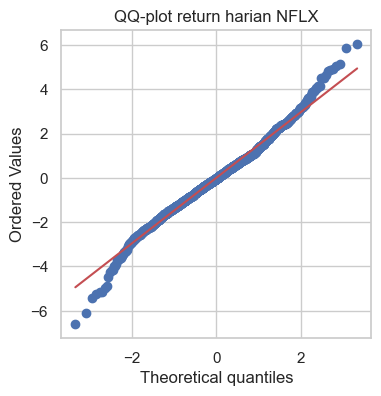

Kurtosis (normal = 0): 1.23


In [12]:
sp500_px = load('sp500_data.csv.gz', index_col=0)
nflx = sp500_px['NFLX']
nflx = np.diff(np.log(nflx[nflx > 0]))

fig, ax = plt.subplots(figsize=(4, 4))
stats.probplot(nflx, plot=ax)
ax.set_title('QQ-plot return harian NFLX')
plt.show()
print('Kurtosis (normal = 0):', stats.kurtosis(nflx).round(2))

Titik-titik di kedua ujung melenceng jauh dari garis: nilai rendah **lebih rendah** dan nilai tinggi **lebih tinggi** daripada normal → *fat tails*.

## 8. Distribusi Student's t

**Distribusi t** berbentuk mirip normal, tetapi ekornya sedikit lebih tebal. Dikembangkan oleh W. S. Gosset (nama samaran *Student*) saat bekerja di pabrik bir Guinness.

- **n** — ukuran sampel.
- **Degrees of freedom (df)** — parameter yang membuat distribusi t menyesuaikan diri dengan ukuran sampel, statistik, dan jumlah grup. Semakin besar df, distribusi t semakin mendekati normal.

Distribusi t sering dipakai sebagai acuan untuk distribusi mean sampel, selisih dua mean sampel, parameter regresi, dll. CI mean berbasis t:

$$\bar{x} \pm t_{n-1}(0.05) \cdot \frac{s}{\sqrt{n}}$$

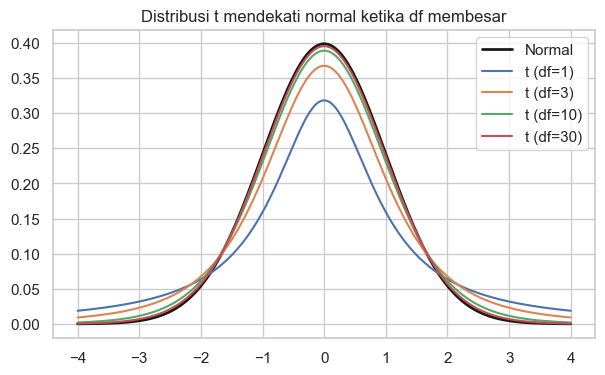

df=   5: t kritis = 2.571   (normal: 1.960)
df=  30: t kritis = 2.042   (normal: 1.960)
df=1000: t kritis = 1.962   (normal: 1.960)


In [13]:
x = np.linspace(-4, 4, 400)
plt.figure(figsize=(7, 4))
plt.plot(x, stats.norm.pdf(x), 'k', lw=2, label='Normal')
for df in [1, 3, 10, 30]:
    plt.plot(x, stats.t.pdf(x, df), label=f't (df={df})')
plt.legend()
plt.title('Distribusi t mendekati normal ketika df membesar')
plt.show()

# Nilai kritis 95% dua sisi
for df in [5, 30, 1000]:
    print(f'df={df:4d}: t kritis = {stats.t.ppf(0.975, df):.3f}   (normal: {stats.norm.ppf(0.975):.3f})')

## 9. Distribusi Binomial

Distribusi binomial adalah distribusi jumlah **sukses** dalam $n$ **trial** independen, masing-masing dengan probabilitas sukses $p$ yang sama.

- **Trial** — kejadian dengan hasil diskrit (misal lempar koin).
- **Success** — hasil yang menjadi perhatian (sinonim: 1, sebagai lawan dari 0).
- **Binomial** — punya dua hasil (ya/tidak, 0/1).
- **Binomial trial / Bernoulli trial** — trial dengan dua hasil.

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

Mean = $n p$, variance = $n p (1-p)$. Untuk $n$ besar dan $p$ tidak terlalu dekat 0 atau 1, distribusi binomial dapat didekati dengan distribusi normal.

Contoh: probabilitas sebuah klik menghasilkan penjualan = 0.02. Berapa probabilitas **tidak ada** penjualan dalam 200 klik?

P(X = 2 | n=5, p=0.1)  : 0.07289999999999992
P(X <= 2 | n=5, p=0.1) : 0.99144
P(0 penjualan dalam 200 klik, p=0.02): 0.017587946605721567
Mean teoretis 4.00 | simulasi 4.01
Var  teoretis 3.92 | simulasi 3.96


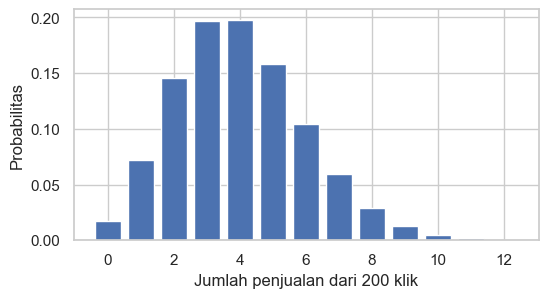

In [14]:
print('P(X = 2 | n=5, p=0.1)  :', stats.binom.pmf(2, n=5, p=0.1))
print('P(X <= 2 | n=5, p=0.1) :', stats.binom.cdf(2, n=5, p=0.1))
print('P(0 penjualan dalam 200 klik, p=0.02):', stats.binom.pmf(0, n=200, p=0.02))

# Mean & variance teoretis vs simulasi
n, p = 200, 0.02
sim = rng.binomial(n, p, size=100_000)
print(f'Mean teoretis {n*p:.2f} | simulasi {sim.mean():.2f}')
print(f'Var  teoretis {n*p*(1-p):.2f} | simulasi {sim.var():.2f}')

k = np.arange(0, 13)
plt.figure(figsize=(6, 3))
plt.bar(k, stats.binom.pmf(k, n, p))
plt.xlabel('Jumlah penjualan dari 200 klik')
plt.ylabel('Probabilitas')
plt.show()

## 10. Distribusi Chi-Square dan F

**Chi-square distribution** adalah distribusi dari **jumlah kuadrat** variabel normal standar. Dalam statistik, ia muncul sebagai distribusi dari **statistik chi-square**, yang mengukur sejauh mana hasil observasi dalam tabel kontingensi menyimpang dari nilai yang diharapkan (*expected*) jika tidak ada hubungan antar variabel (null hypothesis):

$$\chi^2 = \sum \frac{(\text{observed} - \text{expected})^2}{\text{expected}}$$

**F distribution** adalah distribusi rasio dua variansi. Dalam praktik, **F-statistic** membandingkan variabilitas *antar* rata-rata grup dengan variabilitas *di dalam* grup (dipakai di ANOVA dan regresi). Kedua distribusi ini akan dipakai di Bab 3.

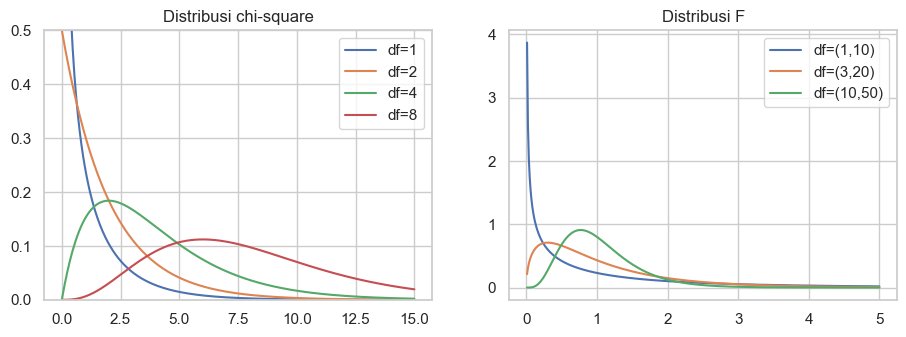

Mean simulasi = 3.998, mean teoretis chi2(4) = 4


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
x = np.linspace(0.01, 15, 400)
for df in [1, 2, 4, 8]:
    axes[0].plot(x, stats.chi2.pdf(x, df), label=f'df={df}')
axes[0].set_title('Distribusi chi-square')
axes[0].set_ylim(0, 0.5)
axes[0].legend()

x = np.linspace(0.01, 5, 400)
for d1, d2 in [(1, 10), (3, 20), (10, 50)]:
    axes[1].plot(x, stats.f.pdf(x, d1, d2), label=f'df=({d1},{d2})')
axes[1].set_title('Distribusi F')
axes[1].legend()
plt.show()

# Bukti: jumlah kuadrat k variabel normal standar ~ chi-square(k)
k = 4
sum_sq = (rng.standard_normal((100_000, k)) ** 2).sum(axis=1)
print(f'Mean simulasi = {sum_sq.mean():.3f}, mean teoretis chi2({k}) = {k}')

## 11. Distribusi Poisson dan Turunannya

- **Lambda (λ)** — rate (per satuan waktu atau ruang) terjadinya suatu event.
- **Poisson distribution** — distribusi frekuensi **jumlah event** dalam satuan waktu/ruang tertentu. Mean = variance = λ.
  $$P(X=k) = \frac{\lambda^k e^{-\lambda}}{k!}$$
  Contoh: jumlah pengunjung situs per menit, jumlah panggilan ke call center per jam.
- **Exponential distribution** — distribusi frekuensi **waktu antar event**. Parameter sama: λ.
- **Weibull distribution** — versi umum dari distribusi eksponensial, di mana rate event boleh **berubah seiring waktu** (parameter *shape* β dan *scale* η). Banyak dipakai dalam analisis *reliability* (umur komponen).

Poisson (lambda=2): [2 1 0 1 2 2 0 3 3 3 0 2 4 2 4 0 2 1 0 2] ...
Exponential mean waktu antar event: 4.74 (teori: 5)
Weibull mean: 4347.1


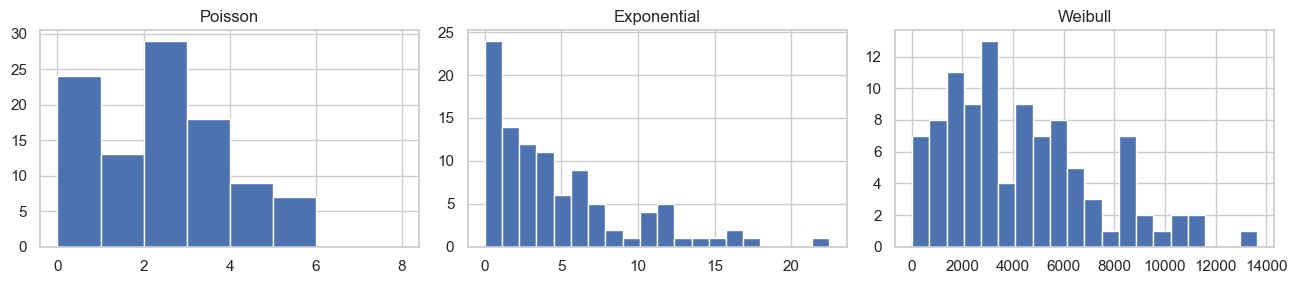

In [16]:
# Rata-rata 2 panggilan per menit ke call center: simulasi 100 menit
poisson_sample = stats.poisson.rvs(2, size=100, random_state=1)
print('Poisson (lambda=2):', poisson_sample[:20], '...')

# Waktu antar panggilan (menit) - exponential dengan rate 0.2 per menit -> scale = 1/0.2
exp_sample = stats.expon.rvs(scale=1 / 0.2, size=100, random_state=1)
print('Exponential mean waktu antar event:', exp_sample.mean().round(2), '(teori: 5)')

# Weibull: shape beta=1.5, scale eta=5000
weibull_sample = stats.weibull_min.rvs(1.5, scale=5000, size=100, random_state=1)
print('Weibull mean:', weibull_sample.mean().round(1))

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
axes[0].hist(poisson_sample, bins=range(0, 9), edgecolor='white'); axes[0].set_title('Poisson')
axes[1].hist(exp_sample, bins=20, edgecolor='white'); axes[1].set_title('Exponential')
axes[2].hist(weibull_sample, bins=20, edgecolor='white'); axes[2].set_title('Weibull')
plt.tight_layout()
plt.show()

In [17]:
# Estimasi failure rate: jika tidak ada event yang teramati, gunakan Poisson untuk menilai
# rate mana yang masih masuk akal. Misal 0 event dalam 20 jam pengamatan:
for rate in [0.01, 0.05, 0.1, 0.2]:
    print(f'rate={rate:.2f}/jam -> P(0 event dalam 20 jam) = {stats.poisson.pmf(0, rate * 20):.3f}')

rate=0.01/jam -> P(0 event dalam 20 jam) = 0.819
rate=0.05/jam -> P(0 event dalam 20 jam) = 0.368
rate=0.10/jam -> P(0 event dalam 20 jam) = 0.135
rate=0.20/jam -> P(0 event dalam 20 jam) = 0.018


## Rangkuman Bab 2

- **Random sampling** mengurangi bias; kualitas data > kuantitas data.
- Waspadai **selection bias**, data snooping, dan **regression to the mean**.
- **Sampling distribution** menggambarkan variabilitas statistik dari sampel ke sampel. Menurut **CLT**, distribusi mean cenderung normal.
- **Standard error** = $s/\sqrt{n}$; turun seiring akar n.
- **Bootstrap** adalah cara serbaguna tanpa asumsi distribusi untuk mengestimasi SE dan **confidence interval**.
- Distribusi normal penting untuk *statistik*, tetapi data mentah sering **long-tailed**.
- **t** untuk sampel kecil, **binomial** untuk jumlah sukses, **chi-square/F** untuk uji hipotesis, **Poisson/exponential/Weibull** untuk event dalam waktu.